In [1]:
import os
import numpy as np
from trianglechain import TriangleChain
from seaborn import color_palette

from msfm.utils import parameters

/Users/arne/miniforge3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


23-06-29 15:26:46    scales.py INF   Setting up healpy to run on 10 CPUs 


# settings

In [2]:
scale_to_prior = True

with_gp_abc = False
with_flow_likelihood = True
with_flow_posterior = False
with_gaussian_mixture = True
with_gaussian_likelihood = True

out_folder = "plots/flow,mixture,gaussian"
os.makedirs(out_folder, exist_ok=True)

In [3]:
def make_contour_plot(
    model_dir,
    n_steps,
    params,
    out_file="plots/contour.png",
    scale_to_prior=True,
    # methods
    with_gp_abc=True,
    with_flow_likelihood=True,
    with_flow_posterior=True,
    with_gaussian_mixture=True,
    with_gaussian_likelihood=True,
):
    # cosmetics
    color_iter = iter(color_palette("tab10"))

    latex_labels = {
        "Om" : r"$\Omega_m$", 
        "s8" : r"$\sigma_8$", 
        "Aia" : r"$A_{IA}$", 
        "n_Aia" : r"$\eta_{A_{IA}}$",
        "bg" : r"$b_g$", 
        "n_bg" : r"$\eta_{b_g}$",
    }

    if scale_to_prior:
        ranges = dict(zip(params, parameters.get_prior_intervals(params)))
    else:
        ranges = None

    # plot
    tri = TriangleChain(
        labels=[latex_labels[param] for param in params],
        scatter_kwargs={"s": 500, "marker": "*", "zorder": 299},
        grid=True,
        fill=True,
        show_values=False,
        bestfit_method="median",
        ranges=ranges,
    )

    # GP ABC
    if with_gp_abc:
        chain = np.load(os.path.join(model_dir, f"chain_{n_steps}_gp_abc.npy"))
        tri.contour_cl(chain, names=params, label="GP ABC", color=next(color_iter))

    # normalizing flow (likelihood)
    if with_flow_likelihood:
        chain = np.load(os.path.join(model_dir, f"chain_{n_steps}_flow.npy"))
        tri.contour_cl(chain, names=params, label="flow (likelihood)", color=next(color_iter))

    # normalizing flow (posterior)
    if with_flow_posterior:
        chain = np.load(os.path.join(model_dir, f"chain_{n_steps}_flow_posterior.npy"))
        tri.contour_cl(chain, names=params, label="flow (posterior)", color=next(color_iter))

    # Gaussian mixture model
    if with_gaussian_mixture:
        chain = np.load(os.path.join(model_dir, f"chain_{n_steps}_mixture.npy"))
        tri.contour_cl(chain, names=params, label="Gaussian (mixture)", color=next(color_iter))

    # Gaussian likelihood
    if with_gaussian_likelihood:
        chain = np.load(os.path.join(model_dir, f"chain_{n_steps}_normal.npy"))
        tri.contour_cl(chain, names=params, label="Gaussian (likelihood)", color=next(color_iter))

    tri.scatter(
        dict(zip(params, parameters.get_fiducials(params))),
        label="fiducial",
        plot_histograms_1D=False,
        color="k",
        show_legend=True,
        scatter_vline_1D=True,
    )

    # save figure
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    tri.fig.savefig(out_file, bbox_inches="tight", dpi=300)


# lensing only

100%|██████████| 6/6 [00:00<00:00, 1216.09it/s]


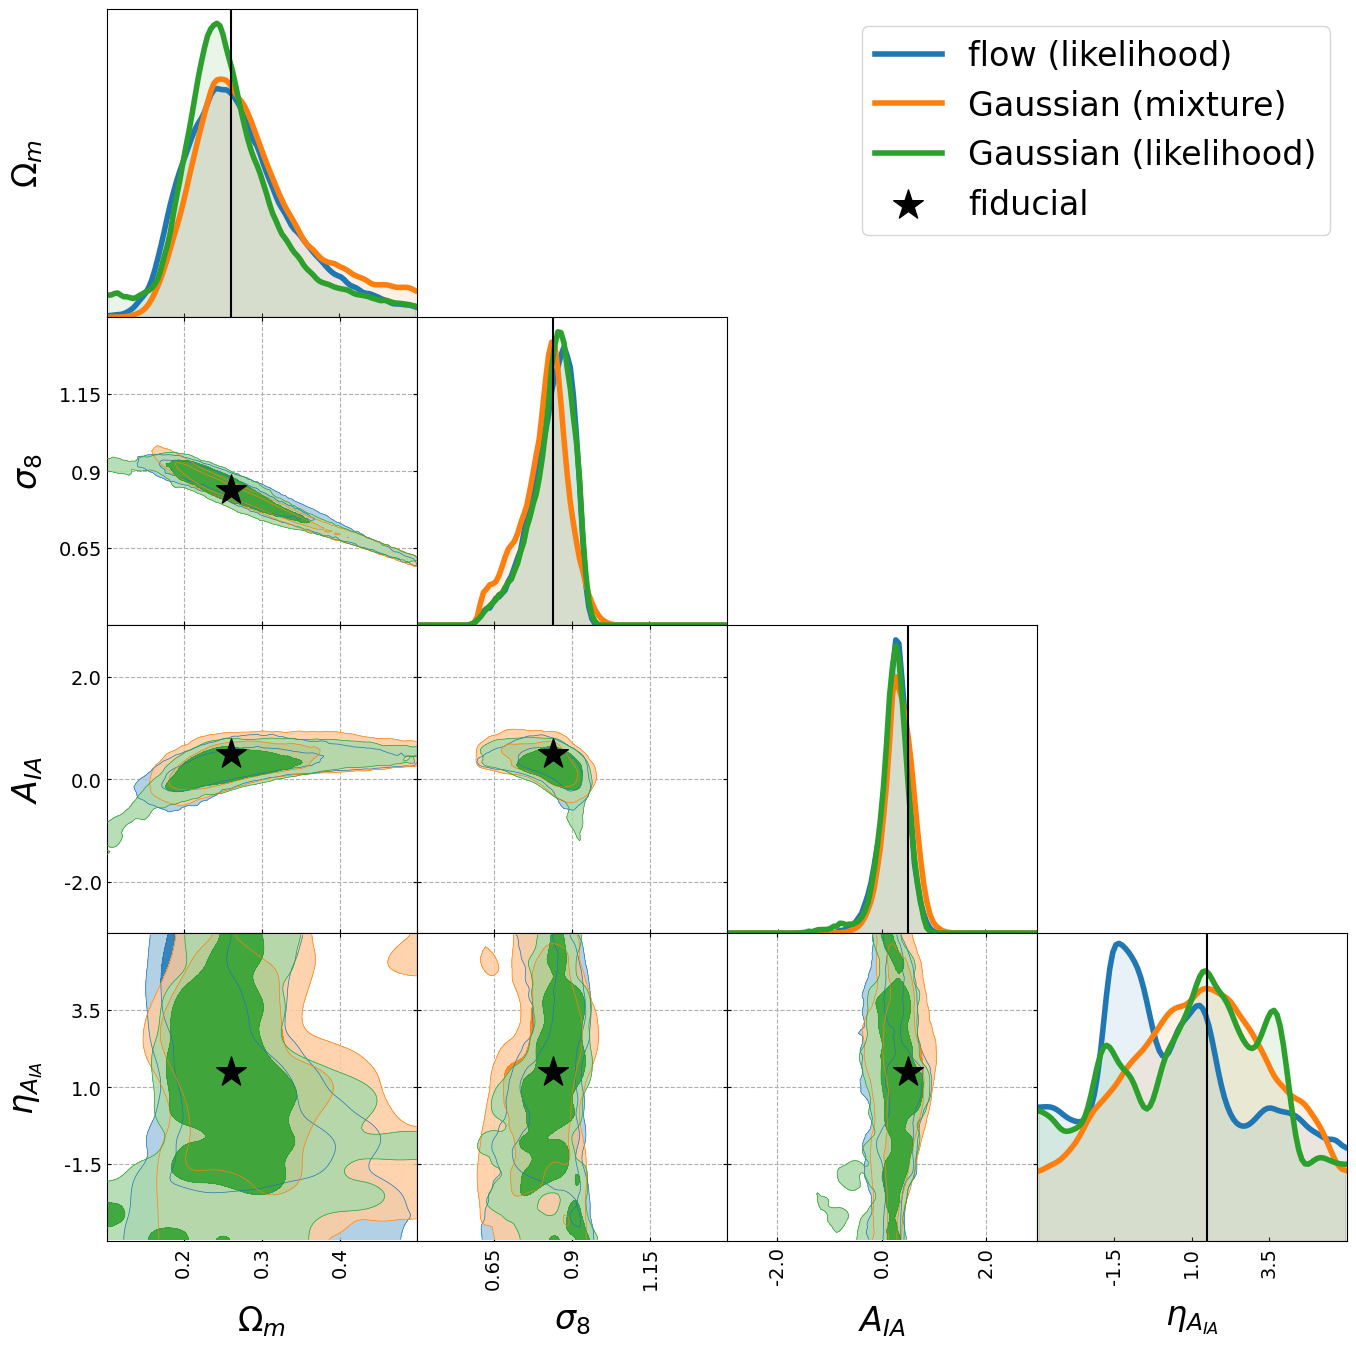

In [4]:
model_dir = "/Users/arne/data/DESY3/models/v3/2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "Aia", "n_Aia"]

make_contour_plot(
    model_dir,
    n_steps,
    params,
    os.path.join(out_folder, "1_lensing_contours.png"),
    scale_to_prior=scale_to_prior,
    with_gp_abc=with_gp_abc,
    with_flow_likelihood=with_flow_likelihood,
    with_flow_posterior=with_flow_posterior,
    with_gaussian_mixture=with_gaussian_mixture,
    with_gaussian_likelihood=with_gaussian_likelihood,
)

# clustering only

100%|██████████| 6/6 [00:00<00:00, 1272.22it/s]


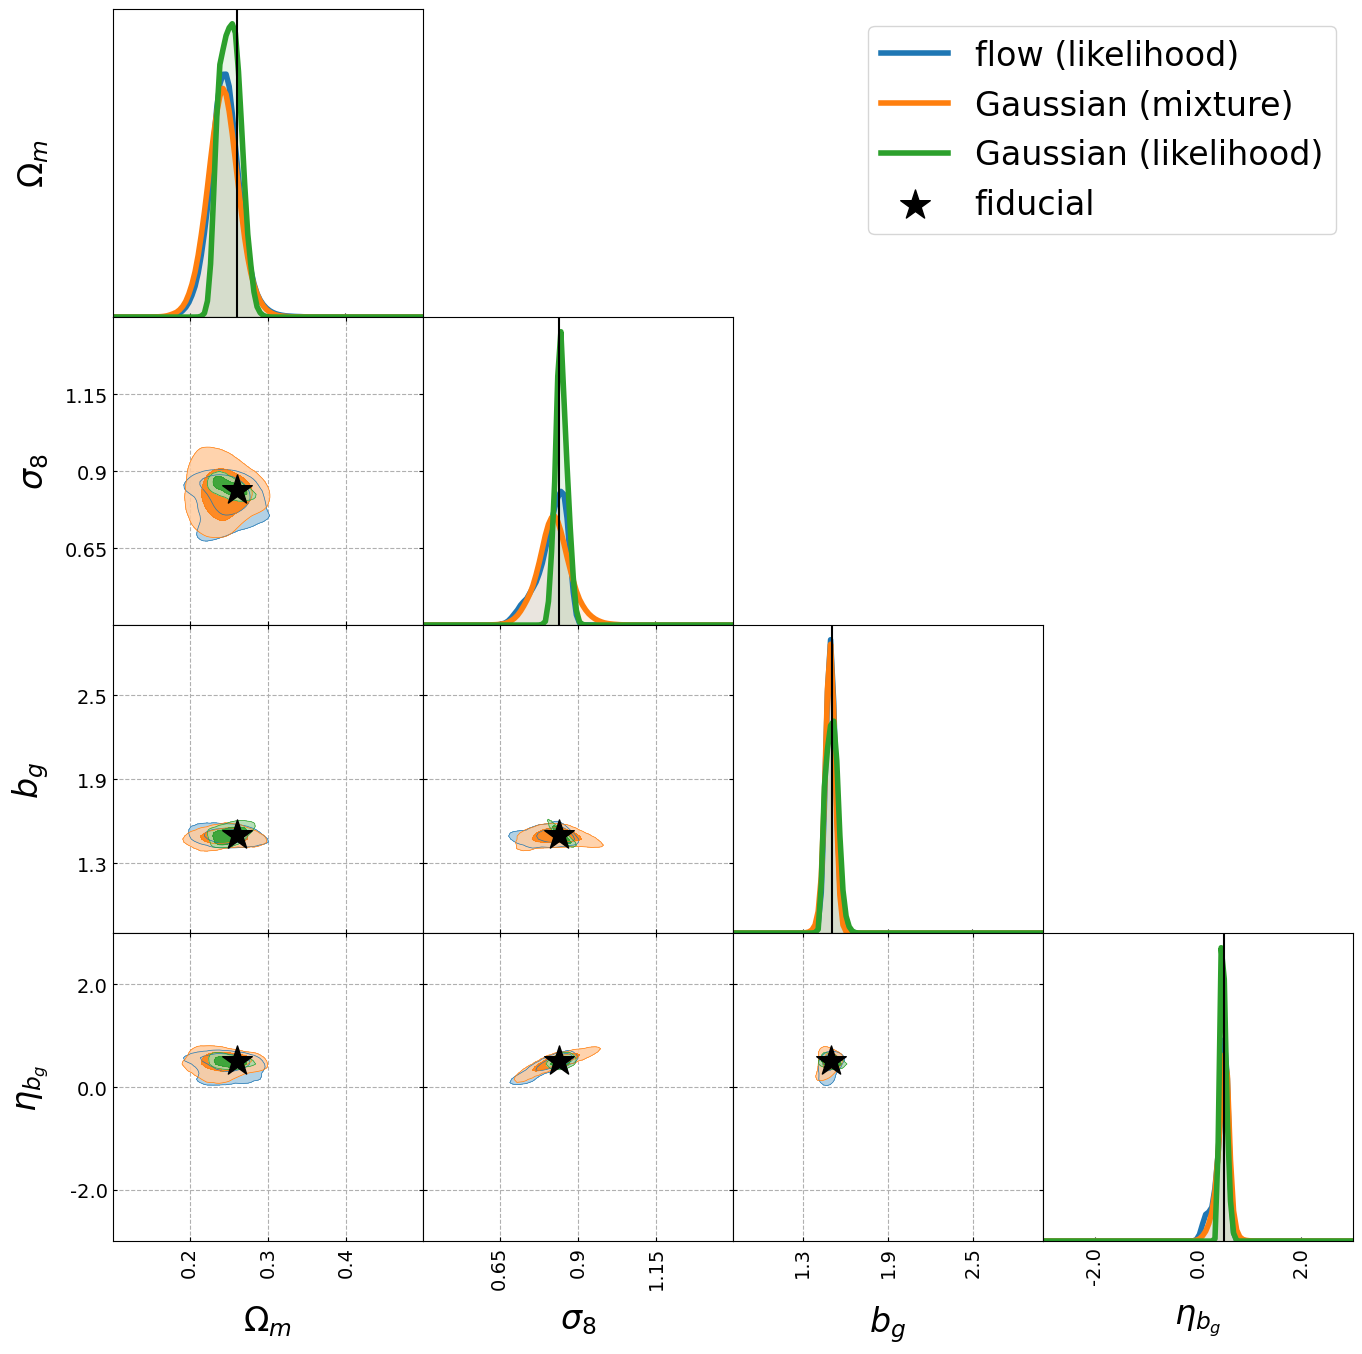

In [5]:
model_dir = "/Users/arne/data/DESY3/models/v3/2023-05-30_01-48-23_resnet_vanilla/"
n_steps = 50000
params = ["Om", "s8", "bg", "n_bg"]

make_contour_plot(
    model_dir,
    n_steps,
    params,
    os.path.join(out_folder, "2_clustering_contours.png"),
    scale_to_prior=scale_to_prior,
    with_gp_abc=with_gp_abc,
    with_flow_likelihood=with_flow_likelihood,
    with_flow_posterior=with_flow_posterior,
    with_gaussian_mixture=with_gaussian_mixture,
    with_gaussian_likelihood=with_gaussian_likelihood,
)

# combined probes

100%|██████████| 15/15 [00:00<00:00, 1407.52it/s]


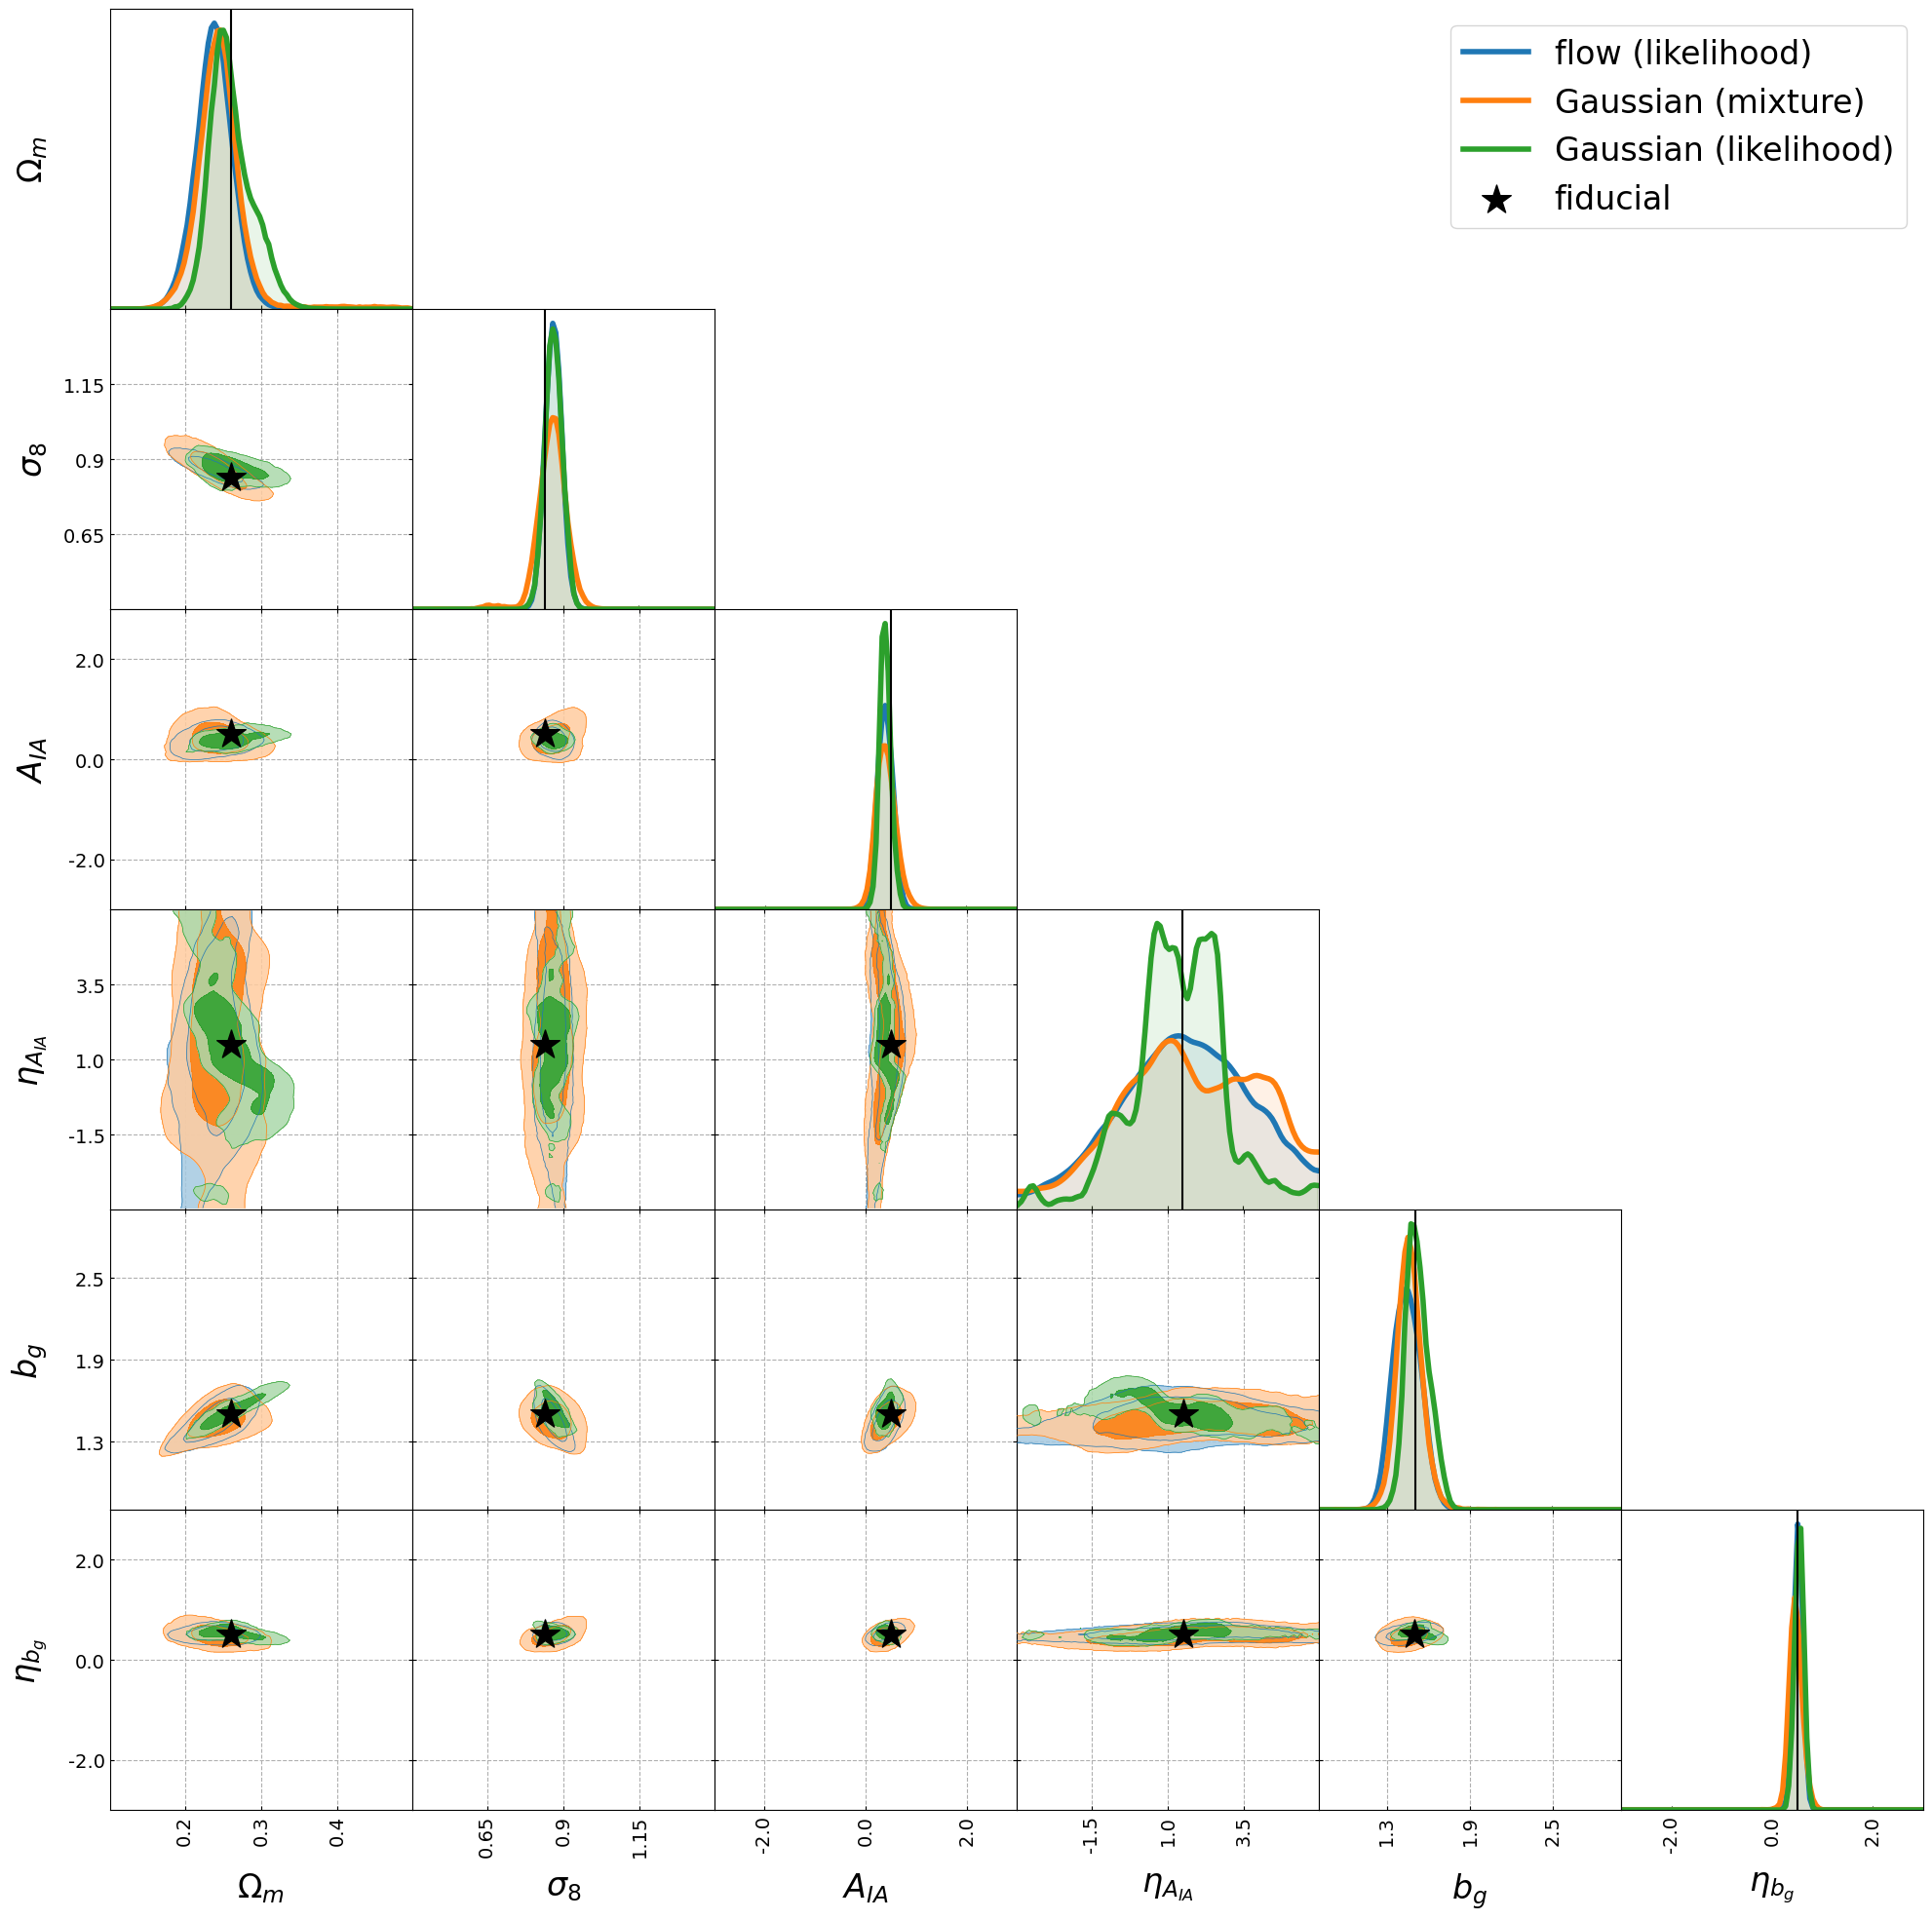

In [6]:
model_dir = "/Users/arne/data/DESY3/models/v3/2023-05-30_10-56-53_resnet_vanilla"
n_steps = 10000
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

make_contour_plot(
    model_dir,
    n_steps,
    params,
    os.path.join(out_folder, "3_combined_contours.png"),
    scale_to_prior=scale_to_prior,
    with_gp_abc=with_gp_abc,
    with_flow_likelihood=with_flow_likelihood,
    with_flow_posterior=with_flow_posterior,
    with_gaussian_mixture=with_gaussian_mixture,
    with_gaussian_likelihood=with_gaussian_likelihood,
)